 PLOT GEBCO 1x1° MASK (0=white, 1=blue)
→ Loading dataset:
  /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/bathymetry/GEBCO_2024_mask_1deg_any_ocean_le_3000m.nc
→ Using variable: mask
→ Coordinates: lat='lat', lon='lon'
→ Building cell edges...
→ Creating map...
→ Plotting mask...
→ Saving figure:
  /remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/bathymetry/GEBCO_2024_mask_1deg_-2000m_cartopy.png


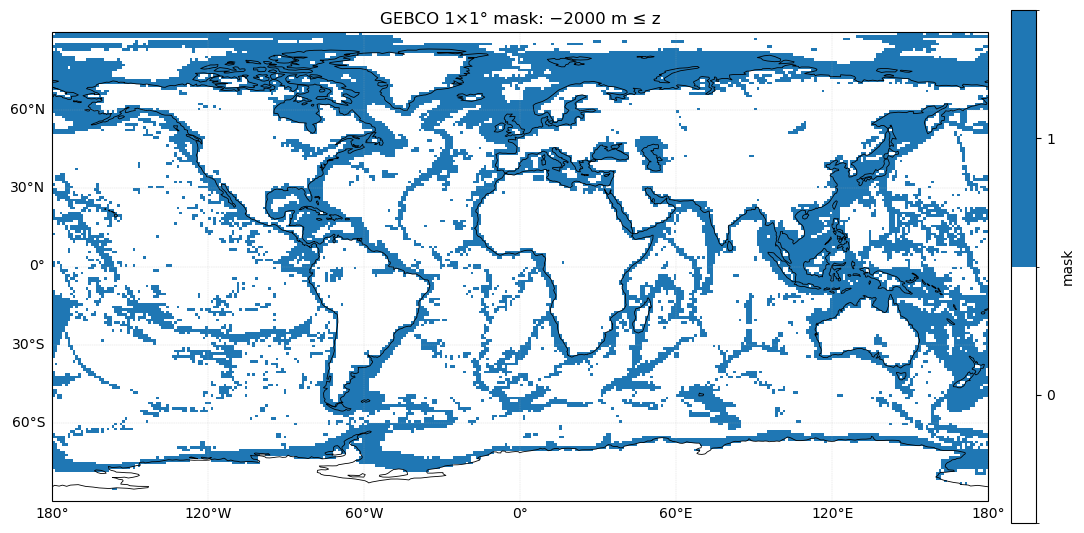

 DONE


In [13]:
#!/usr/bin/env python3
"""
Load the 1x1° GEBCO mask NetCDF and plot it on a Cartopy map.

- 0 = white
- 1 = blue
"""

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

INFILE = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/bathymetry/GEBCO_2024_mask_1deg_any_ocean_le_3000m.nc"
OUTFIG = "/remote/unity/bgc-output/DELAIGUE/SOCAT-FLOATS-OSSE/data/bathymetry/GEBCO_2024_mask_1deg_-2000m_cartopy.png"

# Optional map extent: (lon_min, lon_max, lat_min, lat_max)
EXTENT = None  # e.g. (-80, 20, 0, 70)


def _pick_coord(da, candidates):
    for c in candidates:
        if c in da.coords:
            return c
        if c in da.dims:
            return c
    raise KeyError(f"Could not find any of {candidates} in coords/dims")


def _cell_edges_1d(c):
    """Compute pcolormesh edges from 1D centers."""
    c = np.asarray(c)
    flip = c[1] < c[0]
    if flip:
        c = c[::-1]

    edges = np.empty(c.size + 1)
    edges[1:-1] = 0.5 * (c[:-1] + c[1:])
    edges[0] = c[0] - 0.5 * (c[1] - c[0])
    edges[-1] = c[-1] + 0.5 * (c[-1] - c[-2])

    if flip:
        edges = edges[::-1]
    return edges


def main():
    print("===================================================")
    print(" PLOT GEBCO 1x1° MASK (0=white, 1=blue)")
    print("===================================================")

    print(f"→ Loading dataset:\n  {INFILE}")
    ds = xr.load_dataset(INFILE)

    da = ds["mask"] if "mask" in ds.data_vars else ds[list(ds.data_vars)[0]]
    print(f"→ Using variable: {da.name}")

    lat_name = _pick_coord(da, ["lat", "latitude", "y"])
    lon_name = _pick_coord(da, ["lon", "longitude", "x"])
    print(f"→ Coordinates: lat='{lat_name}', lon='{lon_name}'")

    if da.dims[:2] != (lat_name, lon_name):
        da = da.transpose(lat_name, lon_name)

    lat = da[lat_name].values
    lon = da[lon_name].values
    Z = da.values

    print("→ Building cell edges...")
    lat_e = _cell_edges_1d(lat)
    lon_e = _cell_edges_1d(lon)
    LonE, LatE = np.meshgrid(lon_e, lat_e)

    # --- Colormap: white (0) → blue (1)
    cmap = ListedColormap(["white", "tab:blue"])
    norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)

    print("→ Creating map...")
    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=ccrs.PlateCarree())

    if EXTENT is not None:
        ax.set_extent(EXTENT, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="gray", zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.6)

    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
    gl.top_labels = False
    gl.right_labels = False

    print("→ Plotting mask...")
    m = ax.pcolormesh(
        LonE,
        LatE,
        Z,
        cmap=cmap,
        norm=norm,
        transform=ccrs.PlateCarree(),
        shading="flat",
    )

    cb = plt.colorbar(m, ax=ax, pad=0.02, shrink=0.9, ticks=[0, 1])
    cb.set_label("mask")
    cb.ax.set_yticklabels(["0", "1"])

    ax.set_title("GEBCO 1×1° mask: −2000 m ≤ z")

    print(f"→ Saving figure:\n  {OUTFIG}")
    plt.tight_layout()
    plt.savefig(OUTFIG, dpi=200)
    plt.show()

    print("===================================================")
    print(" DONE")
    print("===================================================")


if __name__ == "__main__":
    main()
